# Introducción a la Ciencia de Datos: Tarea 2



## Introducción
En este trabajo se utilizará el mismo conjunto de datos aplicado en la Tarea 1, derivado del dataset abierto All the News 2.1 - Component One, que reúne artículos de noticias publicados por distintos medios de prensa estadounidenses entre 2016 y 2020. A partir de este conjunto, se trabajará con un subconjunto compuesto por los tres medios con mayor cantidad de artículos, utilizando el texto de las noticias como principal fuente de información.

El objetivo de esta tarea es aplicar técnicas de aprendizaje automático sobre datos de texto. Para ello, se transformarán los artículos a formatos numéricos que puedan ser utilizados por distintos modelos de clasificación, con el fin de predecir a qué medio de prensa pertenece cada noticia a partir de su contenido.

Además, se analizarán diferentes formas de representar el texto, se utilizarán técnicas de reducción de dimensionalidad para visualizar los datos y se evaluará el desempeño de distintos modelos de clasificación. Finalmente, se discutirán los resultados obtenidos, las limitaciones de los métodos utilizados y posibles factores que pueden influir en la capacidad de distinguir entre medios de prensa a partir de sus artículos.

## Cargar bibliotecas (dependencias)

In [ ]:
from time import time
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


## Descarga del dataset


In [ ]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train", cache_dir="../data")
df = ds.to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


all-the-news-2-1-Component-ones-cluster-(…):   0%|          | 0.00/60.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30213 [00:00<?, ? examples/s]

# Parte 1: Dataset y representación numérica de texto

### 1. Preparación del dataset

En primer lugar, se seleccionaron los tres medios de prensa con mayor cantidad de artículos dentro del conjunto de datos. Luego, se aplicó la función clean_text() desarrollada en la Tarea 1 para realizar la limpieza y normalización de los textos.

Posteriormente, el conjunto de datos se dividió en un conjunto de entrenamiento (70%) y un conjunto de prueba (30%) mediante la función train_test_split de scikit-learn. Se utilizó muestreo estratificado (stratify) tomando como referencia el medio de prensa, con el objetivo de mantener aproximadamente la misma proporción de artículos de cada categoría en ambos conjuntos. Además, se fijó un valor para random_state para garantizar la reproducibilidad de los resultados.

In [ ]:
# Cantidad de artículos por medio de prensa
df['publication'].value_counts()

# 3 medios con más artículos
top3 = df['publication'].value_counts().head(3)
top3

# Filtrar df con el top 3 de medios
df_top3 = df[df['publication'].isin(top3.index)].copy()

In [ ]:
texto_completo = " ".join(df_top3.astype(str).values.flatten())

# Obtener todos los caracteres especiales
especiales = sorted(set(
    c for c in texto_completo
    if not c.isalnum() and not c.isspace()
))

print(especiales)

['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~', '\x7f', '\x80', '\x8d', '\x93', '\x99', '¡', '¢', '£', '¥', '©', '«', '¬', '\xad', '®', '°', '´', '·', '»', '¿', '×', '÷', '́', '\u200b', '\u200d', '\u200e', '\u200f', '‐', '‑', '–', '—', '‘', '’', '“', '”', '•', '…', '\u202a', '\u202c', '\u202e', '′', '›', '\u2060', '€', '™', '−', '⎼', '■', '★', '☐', '♥', '♦', '⬥', '、', '。', '《', '》', '【', '】', '\ufeff', '！', '（', '）', '，', '－', '／', '：', '；', '？', '🎶']


In [ ]:
def clean_text(df, column_name):

    # Eliminar primeras palabras hasta el primer "\n"
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # Eliminar signos de puntuación
    for punc in especiales:
        result = result.str.replace(punc, " ")

    # Eliminar números
    result = result.str.replace(r'\d+', '', regex=True)

    return result

In [ ]:
# Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"

df_top3['CleanText'] = clean_text(df_top3, 'article')
df_top3[["article", "CleanText"]].head(5)

,article,CleanText
0,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,feb reuters teva pharmaceutical industrie...
1,The head of the Centers for Medicare and Medic...,the head of the centers for medicare and medic...
5,"(Updates with new first paragraph, adds backgr...",updates with new first paragraph adds backgr...
6,"TORONTO, Dec 4 (Reuters) - Bank of Montreal on...",toronto dec reuters bank of montreal on ...
8,"Calculator Sure, if you choose the right place...",calculator sure if you choose the right place...


In [ ]:
# Particione los datos en train y test (30% test), con muestreo estratificado

X_train, X_test, y_train, y_test = train_test_split(
    df_top3["CleanText"],      # columna con el texto limpio
    df_top3["publication"],     # columna objetivo (medio de prensa)
    test_size=0.30,
    stratify=df_top3["publication"],
    random_state=42
)

In [ ]:
print("Train:", len(X_train))
print("Test:", len(X_test))
print("Total:", len(X_train) + len(X_test))

Train: 10425
Test: 4469
Total: 14894


:### 2. Verificación del balance de clases

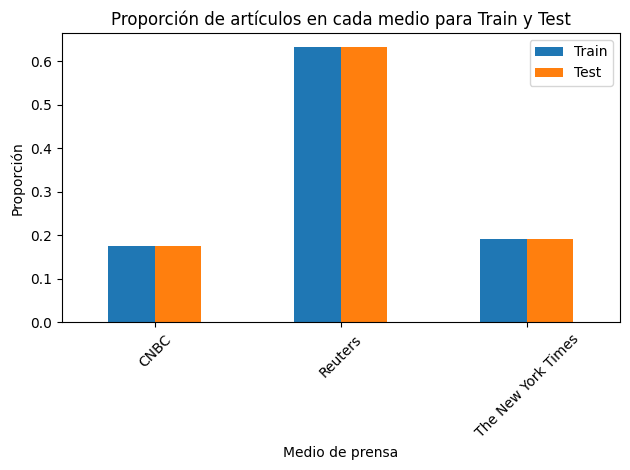

In [ ]:
# Visualización que muestre la proporción de artículos de cada medio en los conjuntos de train y test.

# Proporciones por medio
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

# Unir en un DF
dist_df = pd.DataFrame({
    "Train": train_dist,
    "Test": test_dist
})

# Gráfico
dist_df.plot(kind="bar")
plt.title("Proporción de artículos en cada medio para Train y Test")
plt.ylabel("Proporción")
plt.xlabel("Medio de prensa")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
tabla = pd.DataFrame({
    "Total (n)": df_top3["publication"].value_counts(),
    "Train (n)": y_train.value_counts(),
    "Test (n)": y_test.value_counts(),
    "Train (%)": y_train.value_counts(normalize=True) * 100,
    "Test (%)": y_test.value_counts(normalize=True) * 100
})

tabla.loc["TOTAL"] = [
    len(df_top3),
    len(y_train),
    len(y_test),
    100,
    100
]

# Cantidades a enteros
for col in ["Total (n)", "Train (n)", "Test (n)"]:
    tabla[col] = tabla[col].astype(int)

# Porcentajes
tabla["Train (%)"] = tabla["Train (%)"].map(lambda x: f"{x:.1f}%")
tabla["Test (%)"] = tabla["Test (%)"].map(lambda x: f"{x:.1f}%")

tabla

,Total (n),Train (n),Test (n),Train (%),Test (%)
publication,,,,,
Reuters,9431,6601,2830,63.3%,63.3%
The New York Times,2840,1988,852,19.1%,19.1%
CNBC,2623,1836,787,17.6%,17.6%
TOTAL,14894,10425,4469,100.0%,100.0%


El gráfico y la tabla permiten verificar que la distribución de artículos por medio se conserva en los conjuntos de entrenamiento y prueba. Reuters es el medio con mayor cantidad de artículos (63,3%), seguido por The New York Times (19,1%) y CNBC (17,6%). Se observa que estas proporciones se mantienen prácticamente idénticas en ambas particiones, lo que confirma que el muestreo estratificado preservó el balance original de las clases. Esto es importante porque asegura que el conjunto de prueba sea representativo de los datos utilizados para entrenar los modelos, permitiendo una evaluación más confiable de su desempeño.

### 3. Representación Bag of Words

Los algoritmos de aprendizaje automático no pueden trabajar directamente con texto, por lo que es necesario transformarlo a una representación numérica. Una de las técnicas más simples para hacerlo es **Bag of Words** (BoW).

Esta técnica consiste en construir un vocabulario con todas las palabras que aparecen en el conjunto de entrenamiento y representar cada documento mediante un vector que indica cuántas veces aparece cada palabra. De esta forma, cada columna de la matriz corresponde a una palabra del vocabulario y cada fila corresponde a un documento.

Por ejemplo, si el vocabulario estuviera formado por las palabras ("president", "senate", "government"), el texto "president senate senate" se representaría como (1, 2, 0), mientras que el texto "president government" se representaría como (1, 0, 1). El resultado es una matriz numérica que resume la frecuencia de aparición de cada término en cada documento.

Una característica importante de Bag of Words es que no tiene en cuenta el orden de las palabras dentro del texto, sino únicamente su presencia o frecuencia. Esto simplifica considerablemente la representación, aunque también implica la pérdida de parte de la información contextual contenida en los documentos.

In [ ]:
X_train = X_train.fillna("")
# Vectorizador
vectorizer = CountVectorizer()

# Transformar sobre train
X_train_bow = vectorizer.fit_transform(X_train)

# Tamaño de la matriz
print("Shape:", X_train_bow.shape)

Shape: (10425, 82827)


In [ ]:
# Frecuencia total de cada término en el corpus de entrenamiento
term_counts = np.asarray(X_train_bow.sum(axis=0)).flatten()

vocab = pd.DataFrame({
    "term": vectorizer.get_feature_names_out(),
    "term_count": term_counts
})

# Top 10 palabras más frecuentes
vocab_sorted = vocab.sort_values("term_count", ascending=False)
top_terms = vocab_sorted["term"].head(10).tolist()

print(vocab_sorted.head(10))

# Conteos de esas palabras en el primer documento
doc1 = pd.DataFrame(
    X_train_bow[0, [vectorizer.vocabulary_[t] for t in top_terms]].toarray(),
    columns=top_terms
)

doc1

       term  term_count
73484   the      242626
74298    to      119258
51577    of      108289
2802    and      103364
35188    in       98367
73471  that       46580
51937    on       45063
27068   for       43637
36934    is       34381
63732  said       34303


,the,to,of,and,in,that,on,for,is,said
0,18,7,4,10,10,5,3,2,4,4


In [ ]:
# Tipo de matriz
print(type(X_train_bow))

# Porcentaje de elementos no nulos
total_celdas = X_train_bow.shape[0] * X_train_bow.shape[1]
no_nulos = X_train_bow.nnz

print(f"Total de celdas: {total_celdas:,}")
print(f"Valores no nulos: {no_nulos:,}")
print(f"Porcentaje no nulo: {100 * no_nulos / total_celdas:.4f}%")

<class 'scipy.sparse._csr.csr_matrix'>
Total de celdas: 863,471,475
Valores no nulos: 2,136,292
Porcentaje no nulo: 0.2474%


Al aplicar esta transformación sobre el conjunto de entrenamiento se obtuvo una matriz de dimensiones (10425, 82827). Esto significa que la matriz contiene 10.425 documentos (filas) y un vocabulario de 82.827 palabras distintas (columnas). Cada celda indica la cantidad de veces que una determinada palabra aparece en un determinado documento.

La matriz resultante es una matriz sparse (dispersa) de tipo csr_matrix. En total contiene 863.471.475 celdas, pero solamente 2.136.292 valores distintos de cero, lo que representa apenas 0,2474% del total. En otras palabras, más del 99,7% de los elementos de la matriz son ceros.

Esto ocurre porque cada artículo utiliza únicamente una pequeña parte del vocabulario disponible. Aunque el vocabulario contiene más de 82 mil palabras, un documento individual solo incluye una fracción muy reducida de ellas. Debido a esta característica, almacenar la matriz completa de forma tradicional implicaría un uso innecesariamente elevado de memoria. Por este motivo, scikit-learn utiliza estructuras especiales para matrices dispersas que almacenan únicamente los valores distintos de cero y sus posiciones, reduciendo significativamente los requerimientos de memoria y permitiendo trabajar con conjuntos de datos mucho más grandes.

### 4. Representación TF-IDF


Un n-grama es una secuencia de n palabras consecutivas dentro de un texto. Cuando n = 1 se habla de unigramas, que corresponden a palabras individuales y cuando n = 2 se habla de bigramas, formados por pares de palabras consecutivas. La utilización de n-gramas permite incorporar parte del contexto y capturar expresiones frecuentes que podrían perderse al considerar únicamente palabras aisladas.

Luego de obtener la representación Bag of Words, se aplicó la transformación Term Frequency - Inverse Document Frequency (TF-IDF). Esta técnica asigna un peso a cada término teniendo en cuenta no solo cuántas veces aparece en un documento (Term Frequency), sino también cuán frecuente es en el conjunto total de documentos (Inverse Document Frequency).

In [ ]:
# TODO: Obtenga la representación TF-IDF del conjunto de entrenamiento

tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_bow)
#fit: el transformer recorre X_train_bow y calcula, para cada palabra su IDF
#transform: con esos IDF ya calculados, toma cada conteo de la matriz  y lo multiplica por el IDF


# Muestre el tamaño de la matriz resultante
print("Shape:", X_train_tfidf.shape)
print(type(X_train_tfidf))


Shape: (10425, 82827)
<class 'scipy.sparse._csr.csr_matrix'>


**TF (Term Frequency)** se calcula como:

$$
TF(t,d)=\frac{\text{cantidad de veces que aparece } t \text{ en } d}{\text{cantidad total de palabras en } d}
$$

donde:

- **t** representa el término (palabra) considerado.
- **d** representa el documento.

**IDF (Inverse Document Frequency)** se calcula como:

$$
IDF(t)=\log\left(\frac{N}{df(t)}\right)
$$

donde:

- **N** es la cantidad total de documentos.
- **df(t)** es la cantidad de documentos que contienen el término **t**.

Finalmente, el peso TF-IDF se obtiene multiplicando ambos componentes:

$$
TF-IDF(t,d)=TF(t,d)\times IDF(t)
$$

La idea principal es que las palabras muy frecuentes en todos los documentos suelen aportar poca información para distinguir entre ellos. Por ejemplo, términos como *the*, *and* o *of* aparecen en una gran cantidad de artículos y, por lo tanto, reciben un peso relativamente bajo. En cambio, palabras que aparecen con frecuencia en un documento particular pero no son comunes en el resto del corpus reciben un peso más alto.

A diferencia de Bag of Words, donde los valores representan conteos de palabras, en la representación TF-IDF los valores reflejan la importancia relativa de cada término dentro de cada documento. Esto suele generar una representación más útil para tareas de clasificación de texto.

### 5. Visualización PCA sobre TF-IDF

Para explorar la estructura de los datos, se aplicó Análisis de Componentes Principales (PCA) sobre los vectores TF-IDF del conjunto de entrenamiento y se representaron los documentos utilizando los dos primeros componentes principales. Dado que los vectores de texto tienen una dimensionalidad muy alta, PCA permite proyectarlos en un espacio bidimensional para facilitar su visualización, preservando la mayor cantidad posible de variabilidad de los datos.

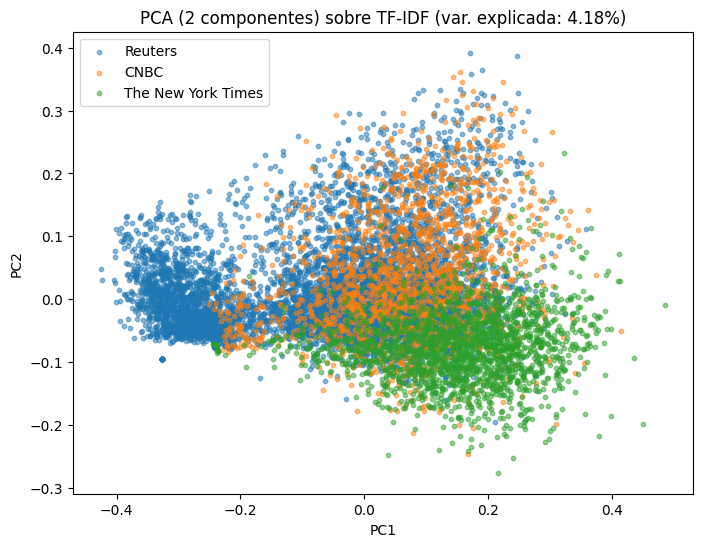

In [ ]:
# TODO: Aplique PCA con 2 componentes sobre X_train_tfidf y grafique los resultados, coloreando los puntos según el medio de prensa.


# Convertir a denso en float32 (la mitad de memoria que float64)
X_train_tfidf_dense = X_train_tfidf.toarray().astype(np.float32)

pca = PCA(n_components=2, svd_solver="randomized", random_state=42)
X_pca = pca.fit_transform(X_train_tfidf_dense)

plt.figure(figsize=(8,6))
for medio in y_train.unique():
    mask = (y_train == medio)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=medio, alpha=0.5, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title(
    f"PCA (2 componentes) sobre TF-IDF (var. explicada: {pca.explained_variance_ratio_.sum():.2%})"
)
plt.show()


El gráfico muestra la proyección de los artículos utilizando los dos primeros componentes principales calculadas sobre los vectores TF-IDF. En este caso, los dos componentes explican aproximadamente el 4,18% de la varianza total, lo que indica que gran parte de la información del conjunto de datos permanece en dimensiones adicionales.

Aun así, se observan algunos patrones interesantes. Los artículos de Reuters tienden a concentrarse hacia los valores negativos del primer componente (PC1), formando un grupo relativamente diferenciado en el sector izquierdo de la figura. Por su parte, los artículos de The New York Times se ubican con mayor frecuencia en valores positivos de PC1 y negativos de PC2, mientras que CNBC ocupa principalmente la zona central y superior del gráfico.

Sin embargo, también existe un importante grado de superposición entre los tres medios, especialmente en la región central del mapa. Esto sugiere que, aunque pueden identificarse ciertas diferencias en el vocabulario utilizado por cada medio, las dos primeras componentes principales no son suficientes para separar claramente las categorías. En consecuencia, la clasificación de los artículos probablemente requiera considerar un número mayor de dimensiones que las representadas en esta visualización.

#### use_idf = FALSE
El caso base utiliza TF-IDF con use_idf=True, que reduce el peso de las palabras que aparecen en muchos documentos. Para evaluar el efecto de esta ponderación, se realizó una segunda visualización utilizando use_idf=False, donde los términos se consideran únicamente según su frecuencia dentro de cada artículo.

Shape: (10425, 82827)


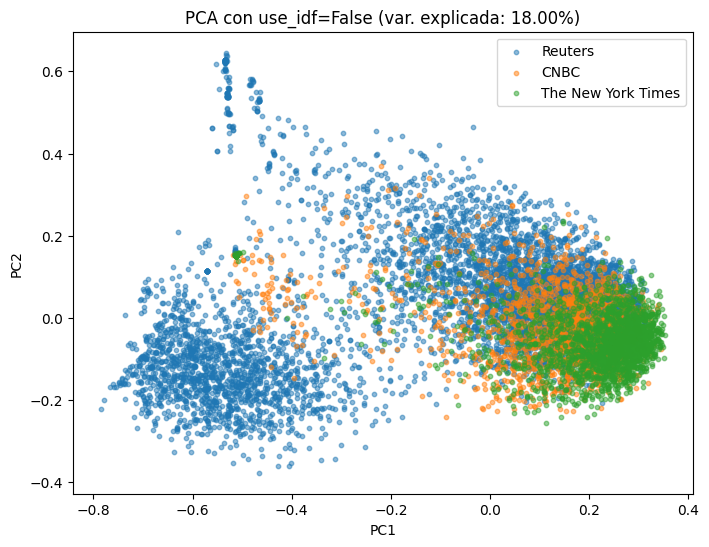

In [ ]:
# TF sin IDF
tf_noidf = TfidfTransformer(use_idf=False)
X_b = tf_noidf.fit_transform(X_train_bow)

print("Shape:", X_b.shape)

# PCA
X_b_dense = X_b.toarray().astype(np.float32)

pca_b = PCA(
    n_components=2,
    svd_solver="randomized",
    random_state=42
)

X_b_pca = pca_b.fit_transform(X_b_dense)

# Gráfico
plt.figure(figsize=(8,6))

for medio in y_train.unique():
    mask = (y_train == medio)
    plt.scatter(
        X_b_pca[mask, 0],
        X_b_pca[mask, 1],
        label=medio,
        alpha=0.5,
        s=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA con use_idf=False (var. explicada: {pca_b.explained_variance_ratio_.sum():.2%})")
plt.legend()
plt.show()

En el gráfico se observa la proyección obtenida al desactivar la componente IDF. En este caso, los dos primeros componentes explican aproximadamente el 18,0% de la varianza, un valor considerablemente mayor que el observado en el caso base (4,18%). Además, la separación visual entre algunos grupos parece más marcada, especialmente para los artículos de Reuters, que forman un conjunto relativamente diferenciado hacia los valores negativos de PC1.

Sin embargo, esta mayor separación no implica necesariamente una mejor representación para tareas de clasificación. Al utilizar use_idf=False, las palabras muy frecuentes adquieren más peso y pueden dominar la representación de los documentos. En cambio, TF-IDF busca destacar términos más específicos y potencialmente más útiles para distinguir entre medios. Por esta razón, aunque el mapa sin IDF muestra una estructura visual más definida y concentra una mayor proporción de la varianza en las primeras componentes, la representación TF-IDF suele ser más adecuada para los modelos de clasificación que se entrenarán posteriormente.

#### Filtrado de stopwords para idioma inglés

A continuación, se evaluó el efecto de eliminar las stop words del idioma inglés mediante el parámetro stop_words='english'. Estas palabras corresponden a términos muy frecuentes, como artículos, preposiciones y conjunciones, que suelen aportar poca información para diferenciar documentos.

Tamaño del vocabulario: 82522


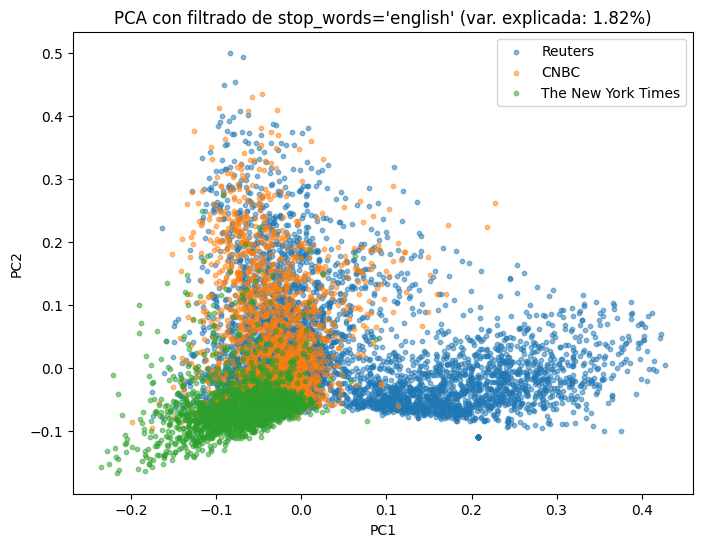

In [ ]:
## TODO: Compare los resultados de PCA con distintas configuraciones del TfidfVectorizer:

# TF-IDF eliminando stopwords en inglés
vec_a = TfidfVectorizer(stop_words='english')
X_a = vec_a.fit_transform(X_train)

print("Tamaño del vocabulario:", X_a.shape[1])

# PCA
X_a_dense = X_a.toarray().astype(np.float32)

pca_a = PCA(
    n_components=2,
    svd_solver="randomized",
    random_state=42
)

X_a_pca = pca_a.fit_transform(X_a_dense)

# Gráfico
plt.figure(figsize=(8,6))

for medio in y_train.unique():
    mask = (y_train == medio)
    plt.scatter(
        X_a_pca[mask, 0],
        X_a_pca[mask, 1],
        label=medio,
        alpha=0.5,
        s=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    f"PCA con filtrado de stop_words='english' (var. explicada: {pca_a.explained_variance_ratio_.sum():.2%})"
)
plt.legend()
plt.show()

En el gráfico se observa la proyección obtenida luego de eliminar las stop words. En este caso, los dos primeros componentes explican aproximadamente el 1,82% de la varianza, un valor menor al observado en el caso base (4,18%).

Visualmente, se puede ver una separación más marcada de los artículos de Reuters, que tienden a concentrarse hacia valores positivos del primer componente (PC1). Sin embargo, los artículos de CNBC y The New York Times continúan presentando un importante grado de superposición, especialmente en la región central del gráfico.

La disminución de la varianza explicada sugiere que las palabras eliminadas contribuían significativamente a la estructura capturada por los primeros componentes principales. No obstante, muchas de estas palabras son muy comunes en todos los documentos y no necesariamente resultan útiles para distinguir entre medios. Por esta razón, aunque la representación bidimensional captura menos varianza, el filtrado de stop words puede seguir siendo beneficioso para tareas de clasificación al reducir ruido y enfocarse en términos más informativos.

#### ngram_range = (1,2)

En esta variante se incorporaron bigramas mediante `ngram_range=(1,2)`, lo que incrementó considerablemente la cantidad de características generadas. Como consecuencia, la matriz TF-IDF resultante aumentó significativamente su dimensionalidad, haciendo que la conversión de la matriz a formato denso, necesaria para aplicar PCA, excediera la memoria RAM disponible.

Para evitar esta limitación, se utilizó **TruncatedSVD**, una técnica de reducción de dimensionalidad especialmente diseñada para trabajar con matrices dispersas (*sparse*), como las obtenidas mediante representaciones TF-IDF.

Mientras que **PCA** transforma los datos proyectándolos sobre nuevos componentes principales, ordenadas según la cantidad de varianza que explican y calculadas a partir de la matriz de covarianza, **TruncatedSVD** aplica directamente la **descomposición en valores singulares** (*Singular Value Decomposition, SVD*) sobre la matriz original. De esta forma, obtiene un conjunto reducido de componentes que concentran la mayor parte de la información sin necesidad de convertir la matriz a formato denso ni centrar previamente los datos.

Por este motivo, TruncatedSVD constituye una alternativa adecuada a PCA cuando se trabaja con matrices TF-IDF de alta dimensionalidad, ya que permite obtener una representación de menor dimensión conservando gran parte de la información, con un consumo de memoria considerablemente menor.

Vocabulario: 1422796


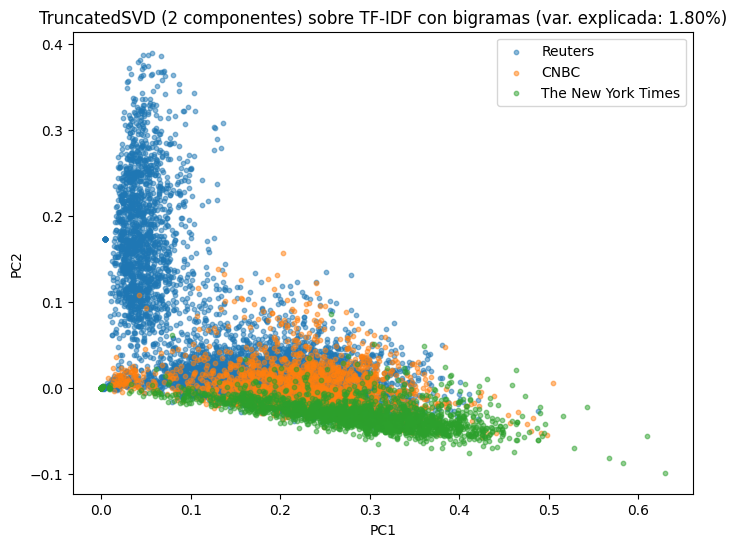

In [ ]:
vec_c = TfidfVectorizer(ngram_range=(1,2))
X_c = vec_c.fit_transform(X_train)

print("Vocabulario:", X_c.shape[1])

svd_c = TruncatedSVD(n_components=2, random_state=42)
X_c_2d = svd_c.fit_transform(X_c)

plt.figure(figsize=(8,6))

for medio in y_train.unique():
    mask = (y_train == medio)
    plt.scatter(
        X_c_2d[mask, 0],
        X_c_2d[mask, 1],
        label=medio,
        alpha=0.5,
        s=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title(
    f"TruncatedSVD (2 componentes) sobre TF-IDF con bigramas (var. explicada: {svd_c.explained_variance_ratio_.sum():.2%})"
)
plt.show()

El gráfico muestra la proyección obtenida al incorporar bigramas (`ngram_range=(1,2)`) en la representación TF-IDF. En comparación con el caso base, se observa una separación más marcada entre los artículos de Reuters y los de los otros dos medios. En particular, Reuters forma un grupo relativamente bien definido hacia valores bajos del primer componente (PC1) y altos del segundo componente (PC2).

Por otro lado, CNBC y *The New York Times* continúan presentando un importante grado de superposición, aunque se aprecia una ligera tendencia a que los artículos de *The New York Times* se concentren en valores más bajos del segundo componente (PC2).

Estos resultados sugieren que la incorporación de bigramas aporta información adicional sobre el contexto de las palabras, permitiendo capturar expresiones características que no pueden representarse utilizando únicamente palabras individuales. Esto parece favorecer la diferenciación de Reuters respecto a los demás medios, aunque los dos primeros componentes siguen sin ser suficientes para lograr una separación completa entre las tres categorías.


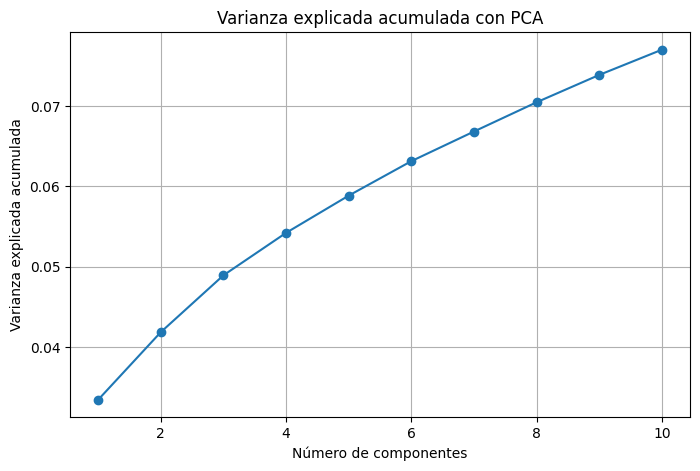

In [ ]:
# TODO: Genere una visualización que muestre cómo varía la varianza explicada
# a medida que se agregan componentes PCA (por ejemplo, hasta 10 componentes).

X = X_train_tfidf.toarray().astype(np.float32)

pca = PCA(n_components=10, random_state=42)
pca.fit(X)

var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

plt.figure(figsize=(8,5))

plt.plot(range(1, 11), var_acum, marker='o')

plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada con PCA")
plt.grid(True)

plt.show()

La varianza explicada acumulada crece de forma lenta a medida que se incorporan componentes. Incluso utilizando 10 componentes, solo se explica aproximadamente un 7–8% de la varianza total. Esto es consistente con la naturaleza de los datos textuales representados mediante TF-IDF, donde la información se encuentra distribuida en un espacio de alta dimensionalidad y gran dispersión.

A partir de los gráficos anteriores, no parece posible separar claramente los tres medios de prensa utilizando únicamente dos componentes. Si bien se observan ciertas zonas con predominio de algunos medios, especialmente en el caso de Reuters, también existe un solapamiento importante entre las categorías, sobre todo entre CNBC y *The New York Times*. Esto sugiere que la información útil para distinguir entre medios no se concentra en solo dos dimensiones, sino que está distribuida entre muchas características del texto.

La separación parcial observada podría deberse a distintos factores. Por un lado, pueden existir diferencias de estilo editorial, como la forma de redactar los titulares, el uso de determinadas expresiones o el tono general de los artículos. Por otro lado, también pueden influir diferencias temáticas entre los medios.

Además, no se puede descartar que parte de la separación observada se deba a pistas explícitas del medio que no hayan sido removidas durante la limpieza del texto. En esta tarea se reutilizó la función clean_text() desarrollada en la Tarea 1, que convierte el texto a minúsculas, elimina signos de puntuación, números y el contenido inicial hasta el primer salto de línea. Sin embargo, esta limpieza no elimina de forma específica nombres de medios, nombres de autores, secciones u otras expresiones recurrentes que podrían aparecer dentro del cuerpo de los artículos.

Por lo tanto, la separación observada no necesariamente refleja únicamente diferencias profundas de estilo editorial, sino también posibles diferencias temáticas o patrones propios del contenido original que permanecieron luego del preprocesamiento aplicado.


# Parte 2: Entrenamiento y Evaluación de Modelos

### 1. Multinomial Naive Bayes

Multinomial Naive Bayes es un algoritmo de clasificación probabilístico basado en el teorema de Bayes. En su versión multinomial, asume que cada documento puede representarse mediante la frecuencia de aparición de sus palabras (o sus pesos TF-IDF) y estima la probabilidad de que pertenezca a cada clase utilizando esa información.

Como primer modelo de clasificación, se entrenó un modelo Multinomial Naive Bayes utilizando el conjunto de entrenamiento representado mediante TF-IDF. Posteriormente, el modelo se aplicó sobre el conjunto de prueba para predecir el medio de prensa de cada artículo y evaluar su desempeño mediante el accuracy, la matriz de confusión y las métricas de precision y recall para cada clase.

In [ ]:
# TODO: Entrene Multinomial Naive Bayes sobre X_train_tfidf

clf = MultinomialNB().fit(X_train_tfidf, y_train)

Accuracy: 0.7026

                    precision    recall  f1-score   support

              CNBC       1.00      0.01      0.02       787
           Reuters       0.68      1.00      0.81      2830
The New York Times       0.95      0.36      0.52       852

          accuracy                           0.70      4469
         macro avg       0.88      0.46      0.45      4469
      weighted avg       0.79      0.70      0.62      4469



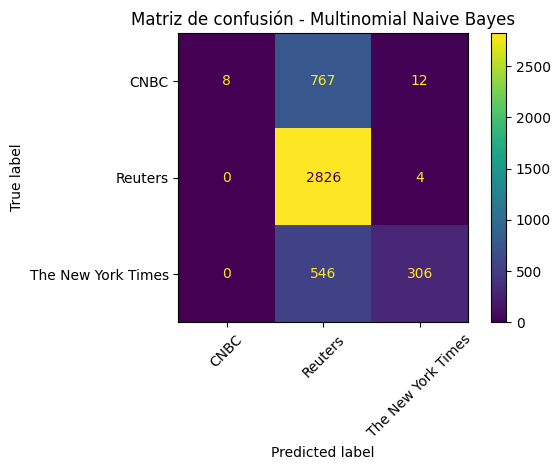

In [ ]:
# TODO: Evalúe el modelo sobre el conjunto de test
X_test = X_test.fillna("")
X_test_bow = vectorizer.transform(X_test)
X_test_tfidf = tfidf_transformer.transform(X_test_bow)

y_pred = clf.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print()
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
plt.title("Matriz de confusión - Multinomial Naive Bayes")
plt.tight_layout()
plt.show()


La matriz de confusión muestra que el modelo clasifica correctamente la gran mayoría de los artículos de Reuters, con 2826 predicciones correctas sobre un total de 2830. En cambio, el desempeño es considerablemente peor para CNBC y The New York Times. En particular, la mayoría de los artículos de CNBC (767 de 787) fueron clasificados incorrectamente como Reuters, mientras que en The New York Times también se observa una cantidad importante de errores (546 de 852), principalmente hacia la misma clase.

Estos resultados indican que el modelo presenta una fuerte tendencia a predecir Reuters, lo que probablemente esté influenciado por el desbalance existente en el conjunto de datos, donde este medio representa la mayor proporción de artículos.

Las métricas de precision y recall reflejan el comportamiento observado en la matriz de confusión. Reuters presenta un recall cercano a 1 (1,00), ya que prácticamente todos sus artículos fueron clasificados correctamente. Sin embargo, su precision es menor (0,68) porque muchos artículos pertenecientes a CNBC y The New York Times fueron clasificados erróneamente como Reuters.

En el caso de CNBC ocurre la situación opuesta. Su precision es muy alta (1,00), lo que indica que cuando el modelo predice CNBC prácticamente siempre acierta. Sin embargo, su recall es extremadamente bajo (0,01), ya que el modelo identifica correctamente solo una pequeña fracción de los artículos de este medio y clasifica la mayoría como Reuters.

Para The New York Times, tanto la precision (0,95) como el recall (0,36) muestran un comportamiento intermedio. Aunque las predicciones realizadas como The New York Times suelen ser correctas, el modelo deja sin identificar una parte importante de sus artículos, clasificándolos principalmente como Reuters.

El accuracy por sí solo no es suficiente para evaluar el desempeño del modelo, ya que no permite identificar diferencias en el comportamiento entre clases. En este caso, el conjunto de datos presenta un desbalance entre medios (con Reuters representando aproximadamente el 63% de los artículos), por lo que un modelo puede obtener un accuracy relativamente alto favoreciendo la predicción de la clase mayoritaria. Sin embargo, esto no garantiza un buen desempeño sobre los medios minoritarios. En efecto, aunque el modelo alcanza un accuracy de 70,3%, presenta un recall de apenas 1% para CNBC y de 36% para The New York Times. Por esta razón, resulta necesario complementar la evaluación con la matriz de confusión y métricas como precision y recall, que permiten analizar el rendimiento del modelo para cada clase y detectar posibles sesgos hacia los medios más frecuentes.

Un aspecto que también podría contribuir a estos resultados es que CNBC suele publicar artículos provenientes de agencias de noticias como Reuters. Si algunos de estos artículos están presentes en el conjunto de datos, es esperable que compartan gran parte del vocabulario y del estilo de redacción, dificultando que el modelo los diferencie. Esto podría explicar, al menos en parte, la gran cantidad de artículos de CNBC clasificados como Reuters.

### 2. Validación cruzada y búsqueda de hiperparámetros

La validación cruzada (cross-validation) es una técnica para estimar el rendimiento real de un modelo de machine learning que consiste en dividir el conjunto de entrenamiento en varios subconjuntos llamados folds. En el esquema más común, k-fold cross-validation, el dataset se separa en k partes (por ejemplo, 5), y el modelo se entrena k veces, utilizando en cada iteración un fold distinto como conjunto de validación y los restantes como conjunto de entrenamiento. De esta forma se obtienen k valores de la métrica de evaluación (como accuracy), que luego se promedian para obtener una estimación más estable del desempeño del modelo. La principal ventaja de este enfoque es que no depende de una única partición train/test, sino que evalúa el modelo en múltiples divisiones de los datos, reduciendo la varianza de la estimación y proporcionando una medida más robusta de su rendimiento.

Para seleccionar los mejores hiperparámetros del modelo se utilizó GridSearchCV, una herramienta de scikit-learn que combina la búsqueda exhaustiva sobre una grilla de hiperparámetros con validación cruzada. De esta forma, cada combinación de parámetros es evaluada utilizando los distintos folds y se calcula el desempeño promedio obtenido. Finalmente, se selecciona automáticamente la configuración que alcanza la mejor métrica promedio.

In [ ]:
# TODO: Defina la grilla de hiperparámetros y ejecute GridSearchCV

#Demora 5 minutos

pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__stop_words": [None, "english"],
    "nb__alpha": [0.1, 1.0]
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    return_train_score=True
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'nb__alpha': 0.1, 'tfidf__ngram_range': (1, 1), 'tfidf__stop_words': 'english'}
0.8125659472422062


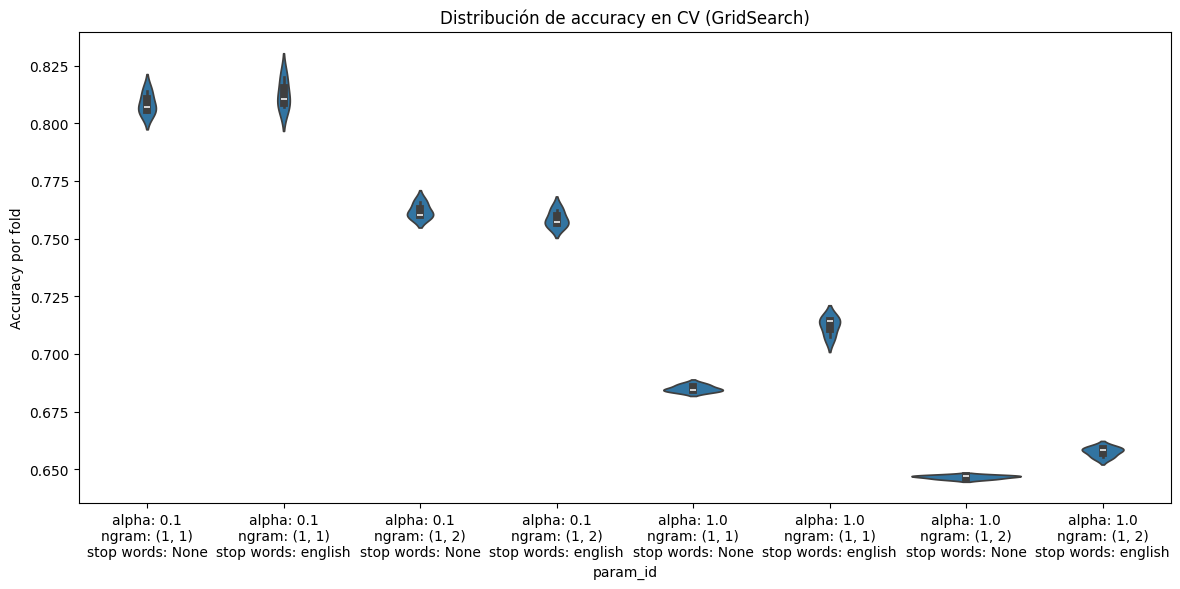

In [ ]:
# TODO: Genere una visualización (por ejemplo, gráfico de violín) que compare
# la accuracy de los distintos modelos entrenados en GridSearchCV,
# mostrando la variabilidad en los distintos splits.

results = pd.DataFrame(grid.cv_results_)

rows = []

for i, params in enumerate(results["params"]):
    for fold in range(3):

        label = (
            f"alpha: {params['nb__alpha']}\n"
            f"ngram: {params['tfidf__ngram_range']}\n"
            f"stop words: {params['tfidf__stop_words']}"
        )

        rows.append({
            "param_id": i,
            "params": label,
            "fold": fold,
            "score": results.loc[i, f"split{fold}_test_score"]
        })

df_violin = pd.DataFrame(rows)

plt.figure(figsize=(12,6))
sns.violinplot(data=df_violin, x="param_id", y="score")

labels = df_violin.drop_duplicates("param_id").sort_values("param_id")["params"].tolist()

plt.xticks(ticks=range(len(labels)), labels=labels)

plt.ylabel("Accuracy por fold")
plt.title("Distribución de accuracy en CV (GridSearch)")
plt.tight_layout()
plt.show()

El gráfico de validación cruzada muestra el desempeño de las distintas combinaciones de hiperparámetros evaluadas mediante GridSearchCV. La mejor configuración corresponde a alpha = 0.1, unigramas (ngram_range=(1,1)) y eliminación de stop words, alcanzando un accuracy promedio de aproximadamente 0,813.

En general, las configuraciones con alpha = 0.1 obtuvieron mejores resultados que aquellas con alpha = 1.0, lo que sugiere que un menor nivel de suavizado se adapta mejor a este conjunto de datos. Asimismo, la eliminación de stop words produjo una mejora consistente en el desempeño, mientras que la incorporación de bigramas (ngram_range=(1,2)) no aportó mejoras y, en la mayoría de los casos, redujo el accuracy obtenido.

Finalmente, se observa una baja variabilidad entre los distintos folds para todas las configuraciones evaluadas. Esto indica que el desempeño del modelo es relativamente estable frente a diferentes particiones del conjunto de entrenamiento y que la estimación obtenida mediante validación cruzada resulta consistente.

### 3. Entrenamiento final con el mejor modelo


Una vez seleccionada la mejor combinación de hiperparámetros mediante GridSearchCV, el modelo se volvió a entrenar utilizando todo el conjunto de entrenamiento disponible. De esta forma, el algoritmo aprovecha la totalidad de los datos para ajustar sus parámetros antes de realizar la evaluación final sobre el conjunto de prueba.

In [ ]:
# TODO: Entrene el mejor modelo sobre todo el conjunto de entrenamiento

# Mejor modelo (según GridSearch)
best_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 1),
        stop_words="english"
    )),
    ("nb", MultinomialNB(alpha=0.1))
])

# Entrenar con TODO el set de entrenamiento
best_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('nb', MultinomialNB(alpha=0.1))])

Accuracy: 0.8104721414186619

Classification report:
                     precision    recall  f1-score   support

              CNBC       0.82      0.35      0.49       787
           Reuters       0.82      0.94      0.88      2830
The New York Times       0.76      0.81      0.78       852

          accuracy                           0.81      4469
         macro avg       0.80      0.70      0.72      4469
      weighted avg       0.81      0.81      0.79      4469


Confusion matrix:
 [[ 275  427   85]
 [  39 2661  130]
 [  22  144  686]]


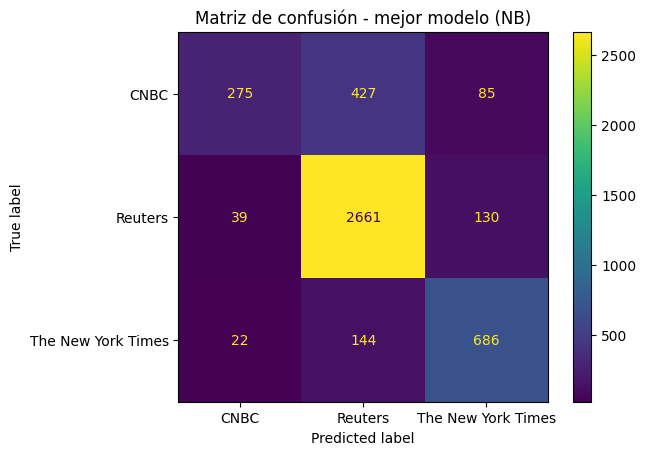

In [ ]:
# TODO: Evalúe el mejor modelo sobre el conjunto de test y reporte métricas finales

# Predicción en test
y_pred = best_model.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Matriz de confusión - mejor modelo (NB)")
plt.show()

El modelo obtuvo un accuracy de aproximadamente 0,81, mejorando el desempeño respecto al modelo inicial. La matriz de confusión muestra que Reuters continúa siendo la clase mejor identificada, con un recall de 0,94. Sin embargo, también se observa una mejora importante en las clases CNBC y The New York Times, especialmente en sus valores de recall, indicando que el modelo logra reconocer una mayor proporción de artículos pertenecientes a estos medios.

A pesar de esta mejora, todavía existe una tendencia a clasificar algunos artículos de CNBC y The New York Times como Reuters. Esto puede estar asociado tanto al desbalance presente en el conjunto de datos como a similitudes en el vocabulario y el contenido de los artículos publicados por estos medios.

### 4. Modelo alternativo


Como modelo alternativo se evaluó la regresión logística, un algoritmo de clasificación lineal que estima, para cada documento, la probabilidad de pertenecer a cada una de las clases a partir de las características de entrada. A diferencia de Multinomial Naive Bayes, este modelo no asume que las palabras son independientes entre sí, sino que aprende durante el entrenamiento los pesos que mejor permiten diferenciar las distintas clases.

Accuracy: 0.871112105616469

Classification report:
                     precision    recall  f1-score   support

              CNBC       0.88      0.52      0.65       787
           Reuters       0.85      0.98      0.91      2830
The New York Times       0.94      0.83      0.88       852

          accuracy                           0.87      4469
         macro avg       0.89      0.78      0.82      4469
      weighted avg       0.87      0.87      0.86      4469


Confusion matrix:
 [[ 408  349   30]
 [  34 2777   19]
 [  21  123  708]]


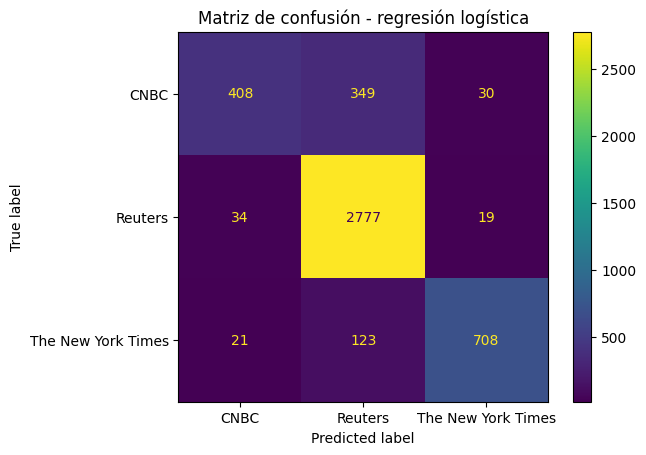

In [ ]:
# TODO: Entrene al menos un modelo alternativo de scikit-learn

# Modelo: TF-IDF + Logistic Regression
log_reg_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 1),
        stop_words="english"
    )),
    ("lr", LogisticRegression(max_iter=1000))
])

# Entrenar
log_reg_model.fit(X_train, y_train)

# Predicción
y_pred_lr = log_reg_model.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(log_reg_model, X_test, y_test)
plt.title("Matriz de confusión - regresión logística")
plt.show()

El modelo de Logistic Regression obtuvo un accuracy de aproximadamente 0,87, superando al mejor modelo basado en Multinomial Naive Bayes, que alcanzó un valor cercano a 0,81.

La matriz de confusión muestra que Reuters continúa siendo la clase con mejor desempeño, con un recall de 0,98. Sin embargo, también se observa una mejora importante en la clasificación de CNBC y The New York Times. En particular, CNBC aumenta su recall de 0,35 a 0,52, mientras que The New York Times alcanza un recall de 0,83. Aunque todavía existe una tendencia a clasificar algunos artículos de CNBC como Reuters, la cantidad de errores disminuye respecto al modelo anterior.

| Métrica | Multinomial Naive Bayes | Regresión logística |
|:---------------------|:-------------------------:|:-------------------:|
| Accuracy | 0.81 | 0.87 |
| Precision (CNBC) | 0.82 | 0.88 |
| Recall (CNBC) | 0.35 | 0.52 |
| Precision (Reuters) | 0.82 | 0.85 |
| Recall (Reuters) | 0.94 | 0.98 |
| Precision (The New York Times) | 0.76 | 0.94 |
| Recall (The New York Times) | 0.81 | 0.83 |

En general, estos resultados muestran que la regresión logística obtiene un mejor desempeño que Multinomial Naive Bayes utilizando las mismas características de entrada. La mejora no solo se observa en el accuracy, sino también en una clasificación más equilibrada de los tres medios de prensa, especialmente en el caso de CNBC.

### 5. Cambio de medio de prensa


En esta parte se modificó el conjunto de datos reemplazando Reuters por The Hill, manteniendo The New York Times y CNBC. El objetivo fue analizar cómo cambia el desempeño del modelo cuando se trabaja con un conjunto de datos más balanceado entre las distintas clases.

En el problema original, Reuters representaba aproximadamente el 63% de los artículos, mientras que los otros dos medios tenían una cantidad considerablemente menor. En cambio, al utilizar The New York Times, CNBC y The Hill, las tres clases presentan un número de artículos mucho más similar, permitiendo evaluar el efecto que tiene el desbalance sobre la clasificación.

Para realizar la comparación, se repitió el mismo procedimiento utilizado anteriormente: se aplicó la función clean_text(), se realizó la partición estratificada en entrenamiento y prueba, se representaron los textos mediante TF-IDF y se entrenó el modelo de regresión logística, utilizando la misma configuración que obtuvo el mejor desempeño en la sección anterior.

In [ ]:
medios = [
    "The New York Times",
    "CNBC",
    "The Hill"
]

df_medios = df[df["publication"].isin(medios)].copy()

pd.DataFrame({
    "Cantidad": df_medios["publication"].value_counts(),
    "Proporción (%)": (df_medios["publication"].value_counts(normalize=True) * 100).round(1)
})

,Cantidad,Proporción (%)
publication,,
The New York Times,2840,36.4
CNBC,2623,33.6
The Hill,2349,30.1


In [ ]:
# Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"

df_medios['CleanText'] = clean_text(df_medios, 'article')
df_medios[["article", "CleanText"]].head(5)

,article,CleanText
1,The head of the Centers for Medicare and Medic...,the head of the centers for medicare and medic...
2,"Benchmark, the venture capital firm that helpe...",benchmark the venture capital firm that helpe...
5,"(Updates with new first paragraph, adds backgr...",updates with new first paragraph adds backgr...
8,"Calculator Sure, if you choose the right place...",calculator sure if you choose the right place...
9,"BOGOTÁ, Colombia — Colombia is investigating a...",bogotá colombia colombia is investigating a...


In [ ]:
# Particione los datos en train y test (30% test), con muestreo estratificado

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    df_medios["CleanText"],      # columna con el texto limpio
    df_medios["publication"],     # columna objetivo (medio de prensa)
    test_size=0.30,
    stratify=df_medios["publication"],
    random_state=42
)

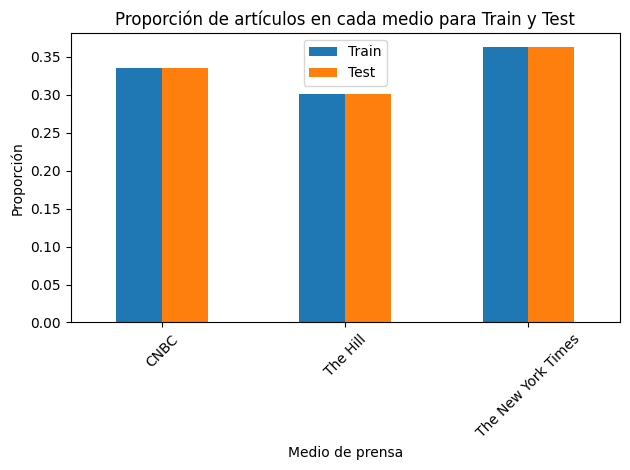

In [ ]:
# Visualización que muestre la proporción de artículos de cada medio en los conjuntos de train y test.

# Proporciones por medio
train_dist2 = y_train2.value_counts(normalize=True).sort_index()
test_dist2 = y_test2.value_counts(normalize=True).sort_index()

# Unir en un DF
dist_df2 = pd.DataFrame({
    "Train": train_dist2,
    "Test": test_dist2
})

# Gráfico
dist_df2.plot(kind="bar")
plt.title("Proporción de artículos en cada medio para Train y Test")
plt.ylabel("Proporción")
plt.xlabel("Medio de prensa")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
X_train2 = X_train2.fillna("")
X_test2 = X_test2.fillna("")

#Bag of words
vectorizer2 = CountVectorizer()

X_train_bow2 = vectorizer2.fit_transform(X_train2)
X_test_bow2 = vectorizer2.transform(X_test2)

#TF-IDF

tfidf_transformer2 = TfidfTransformer()

X_train_tfidf2 = tfidf_transformer2.fit_transform(X_train_bow2)
X_test_tfidf2 = tfidf_transformer2.transform(X_test_bow2)

In [ ]:
#Modelo
best_model2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,1),
        stop_words="english"
    )),
    ("lr", LogisticRegression(max_iter=1000))
])

best_model2.fit(X_train2, y_train2)

y_pred2 = best_model2.predict(X_test2)

print(classification_report(y_test2, y_pred2))
print(confusion_matrix(y_test2, y_pred2))



                    precision    recall  f1-score   support

              CNBC       0.92      0.93      0.92       787
          The Hill       0.99      0.97      0.98       705
The New York Times       0.93      0.94      0.93       852

          accuracy                           0.94      2344
         macro avg       0.95      0.95      0.95      2344
      weighted avg       0.95      0.94      0.95      2344

[[732   6  49]
 [ 11 685   9]
 [ 53   1 798]]


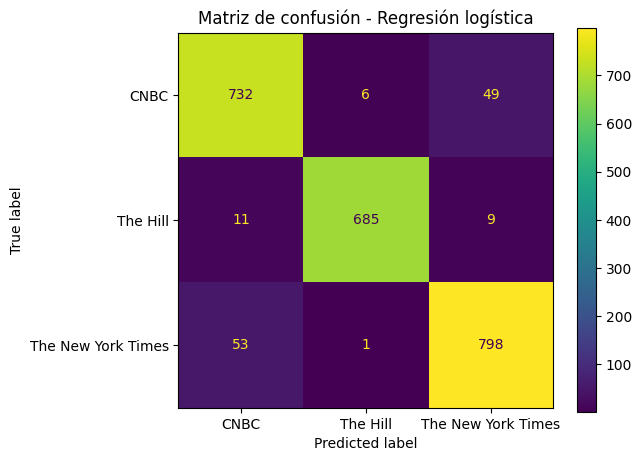

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test2, y_pred2)

plt.title("Matriz de confusión - Regresión logística")
plt.tight_layout()
plt.show()

Al reemplazar Reuters por The Hill, el conjunto de datos quedó considerablemente más balanceado entre los tres medios. En este escenario, el modelo de regresión logística alcanzó un accuracy de aproximadamente 0,94, superior al obtenido en el problema original.

A diferencia del caso anterior, las métricas de precision y recall son altas y bastante similares para las tres clases. Esto indica que el modelo no depende de predecir mayoritariamente una sola categoría, sino que logra identificar correctamente artículos de los tres medios.

La matriz de confusión muestra que The Hill es el medio mejor diferenciado, con muy pocos errores de clasificación. Las principales confusiones se dan entre CNBC y The New York Times, lo que puede deberse a cierta similitud temática o léxica entre algunos de sus artículos.

Estos resultados sugieren que el desbalance del problema original, generado principalmente por la gran cantidad de artículos de Reuters, influía en el desempeño del modelo y en la distribución de los errores. En problemas de clasificación con clases desbalanceadas, técnicas como el sobremuestreo de las clases minoritarias o el submuestreo de la clase mayoritaria podrían ayudar a reducir este efecto, aunque en este caso no fue necesario implementarlas.

### 6. Técnica alternativa de extracción de features

Una alternativa para representar texto son los word embeddings, como Word2Vec, GloVe o FastText. A diferencia de Bag of Words y TF-IDF, donde cada palabra se representa de forma independiente, los embeddings representan cada palabra mediante un vector numérico aprendido a partir de grandes corpus de texto.

La idea principal es que palabras que aparecen en contextos similares obtengan representaciones similares. De esta forma, el modelo puede capturar relaciones semánticas entre palabras, por ejemplo, identificando que car y automobile tienen significados parecidos, aunque sean palabras diferentes.

En comparación con Bag of Words o TF-IDF, se esperaría obtener una representación que capture mejor el significado y las relaciones entre las palabras, ya que incorpora información semántica del texto. Esto podría mejorar el desempeño de los modelos de clasificación, especialmente cuando distintos artículos expresan ideas similares utilizando vocabulario diferente. Sin embargo, estas técnicas suelen requerir un mayor costo computacional y, en muchos casos, modelos previamente entrenados sobre grandes cantidades de texto.

## Notas

Durante la elaboración de este trabajo se utilizó inteligencia artificial como herramienta de apoyo en distintos aspectos técnicos del proyecto, principalmente para el desarrollo y corrección de código, comprensión de errores, manejo de conflictos entre dependencias y mejora de visualizaciones.


## Fuentes

IBM. What are Word Embeddings? IBM Think. https://www.ibm.com/think/topics/word-embeddings

scikit-learn. Cross-validation: evaluating estimator performance. https://scikit-learn.org/stable/modules/cross_validation.html

scikit-learn. GridSearchCV. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

scikit-learn. LogisticRegression. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

scikit-learn. MultinomialNB. https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

scikit-learn. PCA. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

scikit-learn. TruncatedSVD.  https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html


scikit-learn. Working with text data. https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html

TensorFlow. Word embeddings. https://www.tensorflow.org/text/guide/word_embeddings

## Repositorio en github
